# Sections 5 & 6: Estimating 3 Shock Sticky Wage HANK a la Smets & Wouters

I really recommend you go through the simpler estimation step described in the Krusell Smith / Aiyagari notebook I distributed in Canvas before venturing into this more challenging notebook 

**Outline** 

1. **Solve stationary equilibrium/Steady State** after defining model blocks and solve for the 
2. **Compute GE IRFs** to MIT shocks around above Steady State using DAG + fake-news algorithms
3. **Estimation and validation on simulated "fake" data**, testing whether the estimation recovers the parameters defined to simulate the model. The estimation will follow the steps
- MA representation of G GE jacobians storing all the IRFs
- Var-covariance matrix of the model given IRFs and parameters (e.g. how pro-cyclical/lagging are C or i?)
- Log-likelihood of the time series data for a single parameter vector $\theta$ delivering the model's VC matrix
- Log-posterior by adding a desired log prior to the log likelihood
- Do Bayesian Maximum Likelihood, i.e. find the parameter vector $\theta$ that maximizes the posterior of the likelihood of observing the data time series

4. **Estimate on actual data** via Bayesian Maximum Likelihood
- Estimate shocks only (e.g. degree of persistence)  first holding constant GE Jacobians throughout re-evaluations of the likelihood
- Estimate shocks and model parameters (e.g. degree of rigidity)  recomputing the model Jacobians for each evaluation of the likelihood (re-using the Jacobians from the blocks in which we are not estimating parameters)
5. **Smets and Wouters  post-estimation analyses**  
- *Forecast* error variance decomposition (FEVD) -- what shocks play out at different horizons?
- *Historical* shock decomposition -- what shocks seem to have driven the 1970s oil recessions? 

**References**

- Smets, Frank, and Rafael Wouters. 2007. "Shocks and Frictions in US Business Cycles: A Bayesian DSGE Approach." American Economic Review, 97 (3): 586-606.

- Herbst, Edward P. and Frank Schorfheide,Bayesian Estimation of DSGE Models, Princeton University Press, December 2015.

- Auclert, Adrien, Bence Bardóczy, Matthew Rognlie, and Ludwig Straub. 2020. Using the sequence-space Jacobian to solve and estimate heterogeneous-agent models. R&R Econometrica.

- Auclert, Adrien, Matthew Rognlie, and Ludwig Straub. 2020. Micro jumps, macro humps: Monetary policy and business cycles in an estimated HANK model. R&R American Economic Review.

### Package setup

In [1]:
# General python packages
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import scipy.optimize as opt
import statsmodels.api as sm
import time

# Sequence-space Jacobian
import utils
import sequence_jacobian as sj
from sequence_jacobian import draw_dag
import sequence_jacobian.utilities as sj_utils
from sequence_jacobian import simple, het, hetoutput, solved, jacobian

# format plot output to look nice for slides
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['axes.xmargin'] = 0
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=10)

## Define models

We have TFP shocks ${X_{t}}$. The follows a Taylor rule subject to monetary policy shocks ${\boldsymbol{\epsilon}_{t}}$ and follows a fiscal policy rule subject to gov spending shocks ${G_{t}}$, and levies progressive taxes described by ${\lambda}$ and adjusts the intercept of the tax schedule.

The key is going to be to solve the model in blocks. Simple blocks map aggregates to aggregates without needing to deal with distributions. For example, a Taylor rule is one example of such simple block. HA blocks involve the kind of objects we discussed in the last two sections, where aggregate inputs are transformed into aggregate outputs only after aggregating over the distribution of agents.

We typically can solve for aggregate "simple" or "solved" equations either explicitly (e.g. $Y = Y(X,N) = X N$) or implicitly, clearing a residual. More on this below. 

Recall our objective is to arrive to a situation where we have spelled out a system of residual equations of the form

$$ \mathbf{H}\left(\mathbf{U},\mathbf{Z}\right)=0$$ 

and specified exogenous shock paths $dZ$ and endogenous variable paths to solve for $dU$ to a first order via

$$\mathbf{H}_{\mathbf{U}}d\mathbf{U}+\mathbf{H}_{Z}d\mathbf{Z}=0\implies d\mathbf{U}=-\mathbf{H}_{U}^{-1}\mathbf{H}_{Z}d\mathbf{Z}$$ 

To do this, the code will calculate the Jacobians underlying the derivatives of $H$ using the chain rule. Armed with the IRF of a minimal set of endogenous variables, we can construct any IRF for any variable.

$$ \mathbf{Y}=\mathbf{Y}\left(\mathbf{U},\mathbf{Z}\right)\implies d\mathbf{Y}=\mathbf{Y}_{U}d\mathbf{U}+\mathbf{Y}_{Z}d\mathbf{Z}=\left[\mathbf{Y}_{Z}-\mathbf{Y}_{U}\mathbf{H}_{U}^{-1}\mathbf{H}_{Z}\right]d\mathbf{Z}$$ 

Your first task will be to find a DAG that has all your exogenous variables and as few endogenous variables as possible. Typically dynamic variables ($K$ in Krusell Smith, $L$ in Hopenhayn Rogerson, or $A$ or $C$ in Hugget are good choices of dynamic variables, although sometimes is easier to work with prices instead of quatities, i.e. $r$, $w$, which you'll always have to do if you have inflation, i.e. $\pi$, a dynamic asset price).

The key will be for you to determined which variables you can solve for explicitly and which you cannot.

__HA blocks__

$${\begin{aligned}V_{t}\left(a_{-},e\right) & =\max\frac{c^{1-\sigma}}{1-\sigma}+\beta\mathbb{E}\left[V_{t+1}\left(a,e^{\prime}\right)\mid e\right],\quad{Z_{t}=Y_{t}-T_{t}}\\
c+a & =\left(1+r_{t-1}\right)a_{-}+\frac{e^{1-\lambda}}{\mathbb{E}\left[e^{1-\lambda}\right]}Z_{t},\quad a\geq\underline{a}
\end{aligned}
}$$

Recall that importantly for how we solve the model (EGM), cash on hand is the RHS

$$ c+a  =\left(1+r_{t-1}\right)a_{-}+\tilde{e} (Y_{t} - T_t)$$ 

to get policies $c(y,a_{-})$ and $a(y,a_{-})$ written in terms of the $y$ grid, an $n_s$ array where since income shifts symmetrically with $Z$ we can simply use a GE-rescaled $y= \tilde{e} (Y-T)$ as an input into our problem.

In [2]:
@simple
def construct_grids(amax, amin, rho_e, sd_e, nA, nS):
    a_grid = sj_utils.discretize.agrid(amax=amax, n=nA, amin=amin)
    e_grid, e_pdf, Pi = sj_utils.discretize.markov_rouwenhorst(rho=rho_e, sigma=sd_e, N=nS)
    return a_grid, e_grid, e_pdf, Pi

def income_incidence(e_grid, Y, T):
    y_grid = (Y-T) * e_grid
    return y_grid

def household_init(rpost, Y, T, sigma, a_grid, e_grid):
    # initialize guess for policy function iteration
    coh = (1 + rpost) * a_grid[np.newaxis, :] + (Y-T) * e_grid[:, np.newaxis]
    Va = (1 + rpost) * (0.2 * coh) ** (-sigma)
    return Va

@het(exogenous='Pi', policy='a', backward='Va', backward_init=household_init)
def household(Va_p, Pi_p, a_grid, acons, e_grid, y_grid, rpost, beta, sigma):
    """Single backward iteration step using endogenous gridpoint method for households with separable utility.

    y_grid is assumed to be an (nS) array, r is ex-post interest rate in period t
    """
    # backward step of EGM
    uc_nextgrid  = (beta * Pi_p) @ Va_p # Euler FOC
    c_nextgrid   = uc_nextgrid ** (-1 / sigma)
    lhs          = c_nextgrid + a_grid[np.newaxis, :] - y_grid[:, np.newaxis]
    rhs          = (1 + rpost) * a_grid
    a = sj_utils.interpolate.interpolate_y(lhs, rhs, a_grid)
    sj_utils.optimized_routines.setmin(a, acons)
    c = rhs[np.newaxis, :] + y_grid[:, np.newaxis] - a
    uc = c ** (-sigma)
    Va = (1 + rpost) * uc # evelope condition

    # other outputs (will need for NKPC)
    uce = uc * e_grid[:, np.newaxis]

    return Va, a, c, uc, uce

household.add_hetinput(income_incidence, verbose=False)

The reason we need to keep track of marginal utilities is because we are going to introduce nominal rigidities via sticky wages, where unions hire labor demand from firms, which is coming from firms that have flexible prices and thus

$$Y_{t}=X_{t}N_{t} \implies N_t = Y_t/X_t$$

We have a linearized w-Phillips Curve

$$ \pi_{t}^{w}=\kappa_{w}\left(\frac{v^{\prime}\left(N_{t}\right)/u^{\prime}\left(C_{t}\right)}{(1-\lambda)Z_{t}/N_{t}}-\mu\right)+\beta\pi_{t+1}^{w}$$

where $u^{\prime}\left(C_{t}\right) = \int u'(c_{it})e_i di$ (CHECK EXPRESSION) is one of the outputs we get from the household block. Since wages are flexible 

$${P_{t}=\frac{W_{t}}{X_{t}}}\implies {1+\pi_{t}=\left(1+\pi_{wt}\right)\frac{X_{t-1}}{X_{t}}}$$

In the NKPC expression we have $(1-\lambda)Z_{t}/N_{t}$ which is the marginal retention rate.  When ${\lambda=0}$, we have linear taxation, and the marginal retention rate on labor is simply 

$$ Z_{t}=Y_{t}-T_{t}=Y_{t}-\left(1-\tau_{t}\right)Y_{t}=\tau_{t}X_{t}N_{t}\iff\frac{Z_{t}}{N_{t}}=\tau_{t}X_{t}$$


**Market Clearing** 

Labor markets clear already in the union problem. Goods market determining the level of labor demand for production that depends on the level of aggregate demand for goods from households and the government. 

$$ X_{t}N_{t} = Y_{t} = {C_{t}+G_{t}}$$ 

Note that here

$$ {C_{t}=\int c_t(y,a_{-}};\{r_s,y(X_s N_s,T_s)\}_s) D(y,a_{-}) $$

You have learned how to calculate the Jacobian of $C$ wrt each input, either the vector $y$ or the scalar $r$.

Finally, asset markets clear, and since there is no profits, 

$${A_{t}=B_{t}}$$

where

$$ {A_{t}=\int a_{-} D(y,a_{-}};\{r_s,X_s N_s,T_s\}_s) $$ 

You have also learned how to calculate the Jacobian of $A$ wrt each input, either the vector $y$ or the scalar $r$.

Importantly, $X_s$, $G_t$, and $\epsilon_t$ are the three exogenous shocks in the model.

__RA block__

With a rep agent, we no longer need to solve for $V_a$ iteratively, since there's a single Euler equation that can be used as a "simple" aggregate dynamic equation.

$$ {C_{t}^{-\sigma}=\beta\left(1+r_{t}\right)C_{t+1}^{-\sigma}}$$

Naturally in the steady state $1 = \beta (1+r) $. 

We further have a single budget constraint 

$$ C_t+A_t = \left(1+r_{t-1}\right) A_{t-1}+ (Y_t - T_t) $$

In the steady state $ C = rA + Y - T$

Solving for the path of $C_t$ given the path of $r_t$ from the Euler equation, let's us pin down the path of $A_t$. There are two of our targets

$$ H_1(\{C_s,r_s\}_s) = \beta\left(1+r_{t}\right)C_{t+1}^{-\sigma} - {C_{t}^{-\sigma}} = 0$$ 
$$ H_2(\{C_s,A_s,Y_s,T_s,r_s\}_s) = \left(1+r_{t-1}\right) A_{t-1}+ (Y_t - T_t) - C_t - A_t = 0 $$

Which can be solved via the mix of Newton and Bisection Broyden method that we have used before. 


In [3]:
@solved(unknowns={'C': 1., 'A': 1.}, targets=['Cres','Ares'], solver="broyden_custom")
def household_ra(C, A, r, rpost, Y, T, beta, sigma):
    Cres = beta * (1 + r) * C(1)**(-sigma) - C**(-sigma)
    Ares = (1 + rpost) * A(-1) + Y-T - C - A
    return Cres, Ares

Note they set up the `(-1)` notation to refer to state variables like in Dynare for MATLAB.

__Other model blocks__


The government must satisfy a budget constraint

$${B_{t}=\left(1+r_{t-1}\right)B_{t-1}+G_{t}-T_{t}}$$

and sets $G_{t}$ exogenously, but follows a fiscal rule

$${T_{t}=T+\phi_{T}\left(B_{t-1}-B\right)}$$

Again set up the appropriate residuals $H$

In the steady state we have that the fiscal rule does not matter: $0 = 0$ and that $T  = r B + G$ for us to calibrate, and assume $G = 0$, which means that $T = r B$, and $Z = 1 - rB$ for the household block.



In [4]:
@simple
def rpost_simple(r):
    rpost = r(-1)
    return rpost

@solved(unknowns={'B': 0}, targets=['Bres'], solver="brentq")
def fiscal_TBrule(r, G, B, Tss, phi_T):
    T = Tss + phi_T*(B(-1)-B.ss)
    Bres = (1+r(-1))*B(-1) + G - T - B
    return T, Bres


Again `(-1)` notation to refers to state variables like in Dynare for MATLAB.

Monetary policy determines $i_{t}$, and together with the Fisher equation, pins down $r_{t}$

$${r_{t}=i+\phi_{\pi}\pi_{t}-\pi_{t+1}+\epsilon_{t}}$$

$$r_{t}=i_{t}-\pi_{t+1}$$


Via $\phi_{T}$ and $\phi_{\pi}$, interest rates respond to current inflation and taxes to the level of debt. In turn, governments try to cool the economy when past shocks have overheated it ($\pi_{t}$ is high) or generated a lot of debt ($B_{t-1}$) due to deficits.

In the steady state $\pi = 0$ and $ r = i $. 

In [5]:
@simple
def monetary_taylor(pi,ishock,rss,phi_pi):
    i = rss + phi_pi*pi + ishock
    r = i - pi(1)
    return i, r


The linearized w-Phillips Curve defines $\pi^w$ 

$$ \pi_{t}^{w}=\kappa_{w}\left(\frac{v^{\prime}\left(N_{t}\right)/u^{\prime}\left(C_{t}\right)}{(1-\lambda)Z_{t}/N_{t}}-\mu\right)+\beta\pi_{t+1}^{w}$$

This is defined recursively as an asset price, much like the $A^f$ stock market value we had on the firm problem. Instead of dividends, each period's flow returns are dynamic wedges relative to the static intra-temporal labor choice FOC, which applies in the $\pi = 0$ steady state where

$$ v^{\prime}\left(N\right)= \mu u^{\prime}\left(C\right)(1-\lambda)\frac{(Y-T)}{N}$$ 
 
Since we'll target $Y=1$ we will have $N = 1/X$ and we will calibrate a $\phi$ and $X$ parameter above to deliver us $Y=1$ for $v^{\prime}\left((1/X)\right)= \mu u^{\prime}\left(1\right)(1-\lambda)X$ 


Further in the steady state prices are fixed to say $P=1$ without inflation so that, since firms are competitive,

$$ 1=\frac{W}{X}\implies W = X$$ 

which is fixed in the steady state

In [6]:
@simple
def nkpc(pi, Y, X, C, kappa_w, vphi, frisch, markup_ss, eis, beta):
    piw = pi + X - X(-1)
    N = Y/X
    piwres = kappa_w*(vphi*(N)**(1/frisch)- 1/markup_ss*X*C**(-1/eis)) + beta*piw(1) - piw
    return piwres, piw, N

Finally, we have market clearing conditions, written again in $H$ form.

$$ Y_{t} = {C_{t}+G_{t}}$$ 

$${A_{t}=B_{t}}$$

both of which hold in the steady state dropping $t$. In the steady state with $G=0$ we will have consumption being supply determined $C = Y = 1$ and $A = B = T/r$. We are further going to hit $B = 0$ so that $T = 0$ in the steady state, so the model boils down to Huggett

$$ Z = Y - 0,\quad A = 0$$


In [7]:

@simple
def mkt_clearing(A, B, Y, C, G):
    asset_mkt = A - B
    goods_mkt = C + G - Y
    return asset_mkt, goods_mkt

__Define DAG__

Tell the model what are your exogenous $Z_t = (\epsilon_t,X_t,G_t)$, and what are your endogenous variables $U_t = (Y_t,\pi_t)$, and which are all your blocks (simple and messy), and among those, which are the targets you need to clear (i.e. the ones that cannot be solved for explicitly), or $H$s. In this case, we can boil everything down to (1) Asset Market Clearing and (2) NKPC (two sets of equations for two sets of unknowns).

$$ \mathbf{H}\left(\mathbf{U},\mathbf{Z}\right)=0$$ 

and specified exogenous shock paths $dZ$ and endogenous variable paths to solve for $dU$ to a first order via

$$\mathbf{H}_{\mathbf{U}}d\mathbf{U}+\mathbf{H}_{Z}d\mathbf{Z}=0\implies d\mathbf{U}=-\mathbf{H}_{U}^{-1}\mathbf{H}_{Z}d\mathbf{Z}$$ 

Again, armed with $U(Z)$ we can solve for any aggregate using the non-$H$ blocks simply linking aggregates together. 

In [8]:
blocks = {}
blocks['ha'] = [household, mkt_clearing, nkpc, rpost_simple, monetary_taylor, fiscal_TBrule]
blocks['ra'] = [household_ra, mkt_clearing, nkpc, rpost_simple, monetary_taylor, fiscal_TBrule]
exogenous = ['ishock','X','G']
targets = ['asset_mkt', 'piwres']
unknowns = ['Y', 'pi']

**Important** as I anticipated when I showed you the sticky price HANK notebook last week that is featured in in the SHADE paper, where they were solving it in terms of 3 unknowns ($Y,w,\pi$), you can actually reduce it even further to only two unknowns, in this case  ($Y,\pi$), as I already anticipated there.

Note also that the blocks are identical for the HA and RA model except for one, the `household` block with `blocks['aa']` where `aa` is the agent type.

## Steady state

We now solve for the steady state to clear markets. In the RANK model we can do this analytically. In HANK, we need to use a solver such as `brentq` for the market clearing conditions given the aggregated consumption and asset investment choices from solving the household block.



In [9]:
def calibrate_ss(amin = -1, phi_T = 0.1, B = 0, G = 0, 
                     beta_min=0.75, beta_max=0.85, nA=500, kappa_w = 0.2, phi_pi = 1.5,
                     model = 'ha', longbond = False, nominal = False, verbose=True): 

    # Set up a dictionary vector with calibration parameters
    ss = {"sigma": 2, "r": 0.01, "tax": 0, "rho_e": 0.92, "sd_e": 0.92,
               "beta_min": beta_min, "beta_max": beta_max, "Y": 1, 'N': 1, 'X': 1, 
               'G': G, 'B': B, 'phi_T': phi_T,
               'kappa_w':kappa_w, 'frisch': 0.5, 'markup_ss': 1.015, 'phi_pi': phi_pi, 
               "nS": 11, "amax": 1000, "amin": amin, "nA": nA, 'acons': amin}

    # Wage, ex-post rate and fiscal block
    ss['w'] = ss['X']
    ss['rss'] = ss['r']
    ss['rpost'] = ss['r']
    ss['T'] = ss['r']*ss['B'] + ss['G']
    ss.update({'Tss': ss['T'], 'Gss': ss['G']})
    ss['eis'] = 1/ss['sigma']
    
    # Calibrate beta
    if model == 'ha': 
        ss = sj.steady_state([household, mkt_clearing, construct_grids], ss, {"beta": (ss["beta_min"], ss["beta_max"])},
                         ["asset_mkt"], verbose=False, consistency_check=True, ttol=1e-14, ctol=1e-10, solver="brentq")
    elif model == 'ra': 
        ss.update({'beta': 1/(1 + ss['r']), 'A': ss['B'], 'C': ss['Y']-ss['G']})
    
    # Calibrate nominal side of the model
    ss.update({'pi': 0, 'piw': 0, 'ishock': 0})
    ss['i'] = ss['r'] + ss['pi']
    ss['vphi'] = ss['Y']/ss['N'] * 1/ss['markup_ss'] * ss['C']**(-1/ss['eis']) * ss['N']**(-1/ss['frisch'])

    # check Walras law (good market clearing condition)
    if verbose==True: print('Walras law = ', ss['Y'] - ss['C'] - ss['G'])
    
    return ss

In [10]:
ss = calibrate_ss()

Walras law =  -1.1806267075087362e-10


We will only need to solve, as in Huggett, for the asset market clearing condition, and check whether the goods marker clearing condition holds by WL.

## Impulse response functions

Given our exog shocks and unknowns we can get the following

$$\mathbf{H}_{\mathbf{U}}d\mathbf{U}+\mathbf{H}_{Z}d\mathbf{Z}=0\implies d\mathbf{U}=-\mathbf{H}_{U}^{-1}\mathbf{H}_{Z}d\mathbf{Z}$$ 

So for given shock paths say $dG_t =\rho_G ^t$  where  $\rho_G$ = 0.7 we can trace out the response of $Y_t,\pi_t$ directly from the Jacobian $J_{U,Z}$, which also will include other Jacobians of other endogenous variables that are defined in the blocks we have provided, which just uses the IFT


$$ \mathbf{Y}=\mathbf{Y}\left(\mathbf{U},\mathbf{Z}\right)\implies d\mathbf{Y}=\mathbf{Y}_{U}d\mathbf{U}+\mathbf{Y}_{Z}d\mathbf{Z}=\left[\mathbf{Y}_{Z}-\mathbf{Y}_{U}\mathbf{H}_{U}^{-1}\mathbf{H}_{Z}\right]d\mathbf{Z}$$ 

These Jacobians are calculated using the fake-news algorithm you saw inn the last PSET together with the chain rule. All the painful stuff you did for that problem set (**and much more!**) can be boiled down to one command that gets a big `G` with all the Jacobians for any $Y$ output with respect to any exogenous shock $Z$. 

`G = sj.get_G(blocks['ra'], exogenous, unknowns, targets, T=T, ss=ss)`

Given such Jacobian, to make an IRF ($dY$) all we need to do is multiply $G dZ$

$$ dY^o = G_{o,z} dZ^z$$

where $o$ index all the aggregate variables we care about (e.g. $C$) and $z$ index all shocks (e.g. $X$)

FOOTNOTE: (**and much more!**) = As we saw on my notes on SSJ in Canvas, for Krusell Smith $H_{t}(\mathbf{K},\mathbf{Z}) = \mathcal{K}_{t}\left(\left\{ r_{s},w_{s}\right\} \right)-K_{t} =  0$. This command calculates Jacobians for each output and for each input in the model, for example $\partial\mathcal{K}/\partial r=\mathcal{J}^{\mathcal{K},r}\text{ and }\partial\mathcal{K}/\partial w=\mathcal{J}^{\mathcal{K},w} $, and then, using the recursive structure in the DAG, "accumulates" them using the Chain Rule: $ \left[\mathbf{H}_{\mathbf{K}}\right]_{t,s}=\frac{\partial\mathcal{K}_{t}}{\partial r_{s+1}}\frac{\partial r_{s+1}}{\partial K_{s}}+\frac{\partial\mathcal{K}_{t}}{\partial w_{s+1}}\frac{\partial w_{s+1}}{\partial K_{s}}-1_{\{s=t\}}$



In [11]:
# Recall we defined above

exogenous = ['ishock','X','G']
targets = ['asset_mkt', 'piwres']
unknowns = ['Y', 'pi']

In [12]:
def irf_make(G,shock,shockname,varlist,T):
    
    irf= {}
    for i, z in enumerate(varlist): 
        if z == shockname:
            irf[z] = shock
        else: 
            try:
                irf[z] = G[z][shockname] @ shock
            except:
                irf[z] = np.zeros(T)

    return irf

__RA model__

Walras law =  0
Dynamic Walras law = 5.83e-12
Dynamic Walras law = 4.95e-12
Dynamic Walras law = 1.04e-12


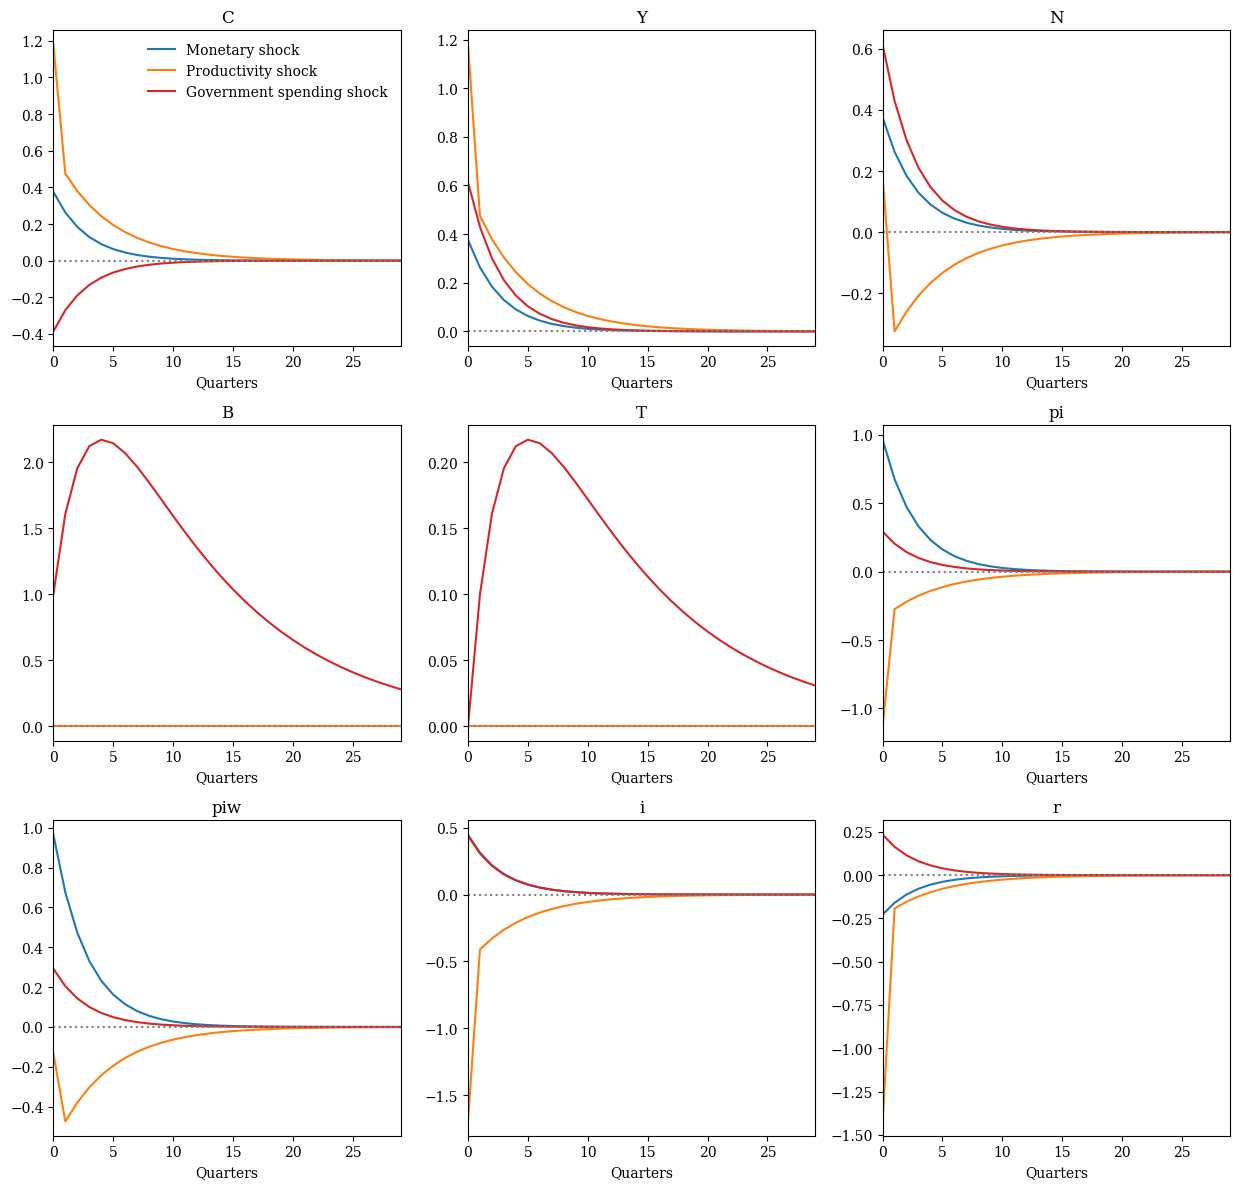

In [13]:
# Steady state
ss = calibrate_ss(model='ra')
T = 500

# Model jacobians
G = sj.get_G(blocks['ra'], exogenous, unknowns, targets, T=T, ss=ss)
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G['goods_mkt']['ishock']))))
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G['goods_mkt']['X']))))
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G['goods_mkt']['G']))))

# Define shocks
shock_list = ['ishock','X','G']
shock = {}
shock['ishock'] = - 0.7 ** np.arange(T)
shock['X'] = 0.8 ** np.arange(T)
shock['G'] = 0.7 ** np.arange(T)

# Get irf by matrix multiplication
irf = {}
varlist = ['C','Y','N','B','T','pi','piw','i','r']
for s in shock_list: irf[s] = utils.irf_make(G,shock[s],s,varlist,T)

# plot
Tplot = 30
plt.figure(figsize=(12.5, 12))
for i,k in enumerate(varlist):
    plt.subplot(3,3,i+1)
    plt.title(k)
    plt.plot(irf['ishock'][k][0:Tplot], color='tab:blue', label = 'Monetary shock')
    plt.plot(irf['X'][k][0:Tplot], color='tab:orange', label = 'Productivity shock')
    plt.plot(irf['G'][k][0:Tplot], color='tab:red', label = 'Government spending shock')
    plt.axhline(y=0, color='#808080', linestyle=':')
    plt.xlabel('Quarters')
    if k =='C' : plt.legend(framealpha=0)
plt.tight_layout()
plt.show()

Can summarize the effect on our main variables as: 
    
    | shock    | Y | pi | r
    | monetary | + | +  | - 
    | TFP      | + | -  | - 
    | G        | + | +  | +
    
(Note TFP actually lowers $N$ after a period, though that shouldn't matter for us)

__HA model__

Walras law =  -1.1806267075087362e-10
Walras law =  -1.1806267075087362e-10
Dynamic Walras law = 1.79e-10
Dynamic Walras law = 6.55e-10
Dynamic Walras law = 1.47e-10
Dynamic Walras law = 1.79e-10
Dynamic Walras law = 6.55e-10
Dynamic Walras law = 2.00e-10


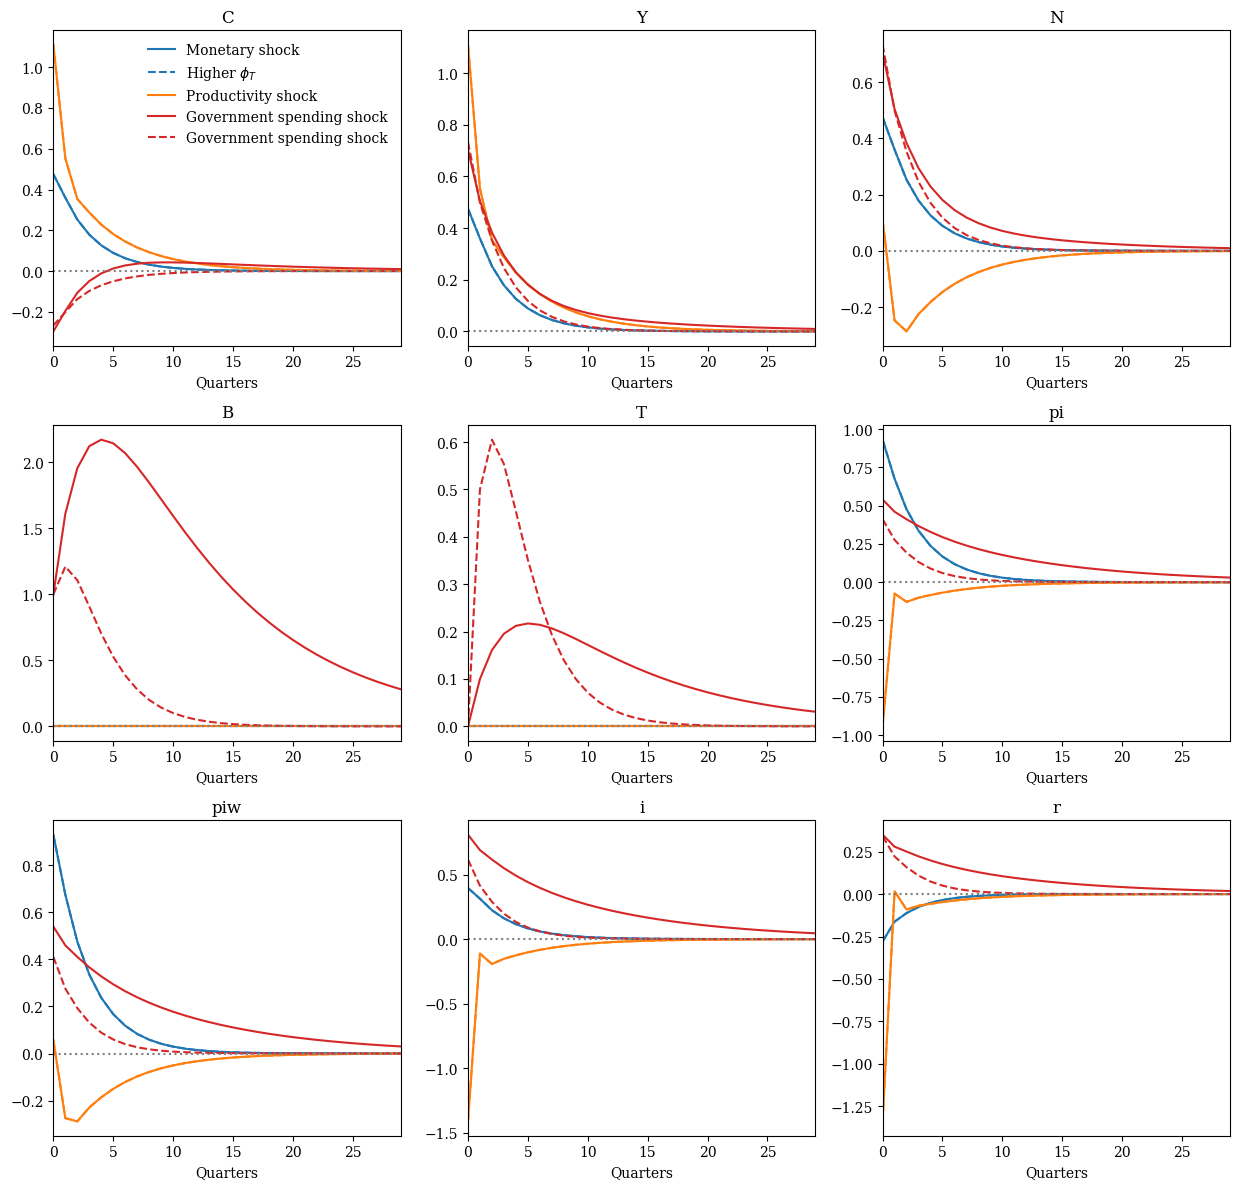

In [14]:
# Steady state
ss = calibrate_ss(model='ha')
ss2 = calibrate_ss(model='ha', phi_T=0.5) # higher phi_T model
T = 500

# Model jacobians
G = sj.get_G(blocks['ha'], exogenous, unknowns, targets, T=T, ss=ss)
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G['goods_mkt']['ishock']))))
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G['goods_mkt']['X']))))
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G['goods_mkt']['G']))))

G2 = sj.get_G(blocks['ha'], exogenous, unknowns, targets, T=T, ss=ss2)
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G2['goods_mkt']['ishock']))))
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G2['goods_mkt']['X']))))
print('Dynamic Walras law = %.2e' %(np.max(np.abs(G2['goods_mkt']['G']))))


# Define shocks
shock_list = ['ishock','X','G']
shock = {}
shock['ishock'] = - 0.7 ** np.arange(T)
shock['X'] = 0.8 ** np.arange(T)
shock['G'] = 0.7 ** np.arange(T)

# Get irf by matrix multiplication
irf = {}
irf2 = {}
varlist = ['C','Y','N','B','T','pi','piw','i','r']
for s in shock_list: irf[s] = utils.irf_make(G,shock[s],s,varlist,T)
for s in shock_list: irf2[s] = utils.irf_make(G2,shock[s],s,varlist,T)
    
# plot
Tplot = 30
plt.figure(figsize=(12.5, 12))
for i,k in enumerate(varlist):
    plt.subplot(3,3,i+1)
    plt.title(k)
    plt.plot(irf['ishock'][k][0:Tplot], color='tab:blue', label = 'Monetary shock')
    plt.plot(irf2['ishock'][k][0:Tplot], '--', color='tab:blue', label = 'Higher $\phi_T$')
    plt.plot(irf['X'][k][0:Tplot], color='tab:orange', label = 'Productivity shock')
    plt.plot(irf2['X'][k][0:Tplot], '--', color='tab:orange')
    plt.plot(irf['G'][k][0:Tplot], color='tab:red', label = 'Government spending shock')
    plt.plot(irf2['G'][k][0:Tplot], '--', color='tab:red', label = 'Government spending shock')
    plt.axhline(y=0, color='#808080', linestyle=':')
    plt.xlabel('Quarters')
    if k =='C' : plt.legend(framealpha=0)
plt.tight_layout()
plt.show()

Same general effects as above. $phi_T$ only affects effect of a $G$ shock. 

In [20]:
# Here we get all the different Jacobians of the model wrt each of the shocks
print(G)
print(G['C']['X'])

{'Uce': {'ishock': array([[ 2.61257990e+00,  9.48080432e-01,  1.96187192e-01, ...,
        -1.05723258e-13, -1.16702763e-13,  0.00000000e+00],
       [ 1.40180918e+01, -3.87241553e+00, -3.10995889e+00, ...,
        -7.12869134e-13, -7.86383481e-13,  0.00000000e+00],
       [-1.18782213e+00,  1.44706610e+01, -3.52290408e+00, ...,
        -6.64609223e-13, -7.33175718e-13,  0.00000000e+00],
       ...,
       [ 8.55925208e-33, -8.23388595e-33,  8.10708495e-33, ...,
        -3.52318275e+00, -3.05526077e+00,  0.00000000e+00],
       [ 9.95550628e-34, -8.10056191e-35, -6.76382758e-33, ...,
         1.43861399e+01, -3.82933904e+00,  0.00000000e+00],
       [-7.75097817e-33, -5.87978972e-33,  8.96480943e-33, ...,
        -1.29675268e+00,  1.40089477e+01,  0.00000000e+00]]), 'X': array([[-7.42590241e+00, -6.66976492e-01, -3.72150400e-01, ...,
         1.60104333e-13,  3.72879146e-13,  8.63362162e-14],
       [-5.32836879e+01,  2.05202852e+01,  2.24291329e+00, ...,
         1.08045280e-12,  2.51

## Simulation

We will simulate series for inflation $\pi_t$, output $Y_t$ and the nominal interest rate $i_t$. We will use it to test our estimate functions.

- Recall that to *simulate* IRFs using the DAG, the rules was: **# endogenous variables = # aggregate targets** to clear markets or asset pricing/no-arbitrage conditions, and we could have however many exogenous shocks we wanted. In this case, we chose to solve for $Y,\pi$. 

- In contrast, to *estimate* the model we will have to follow **# exogenous shocks = # aggregate time series** to match IRFs over. Thus, we need data on another informative aggregate variable, so we add $dX = Y,\pi,i$ to be just-identified.

Recall here that any outcomes is a truncated MA representation using the IRFs 

$$Y_{t}=\sum_{z=1}^{2}\sum_{s=0}^{T-1}m_{s}^{y,z}\epsilon_{t-s}^{z} = \sum_z m^{y,z} \cdot \epsilon^z_\text{flipped}$$ 

where each $m_{s}^{o,z} = d\mathbf{Y}^{o,z}=\mathbf{G}^{o,z}d\mathbf{Z}^{z}.$ 

For the simulation, all we have to do is trace out paths for outcomes via the IRF we computed before

$$m^{o,z} = G_{o,z} dZ^z  = G_{o,z} [\sigma_z \rho_z^t]_t$$

Thus, for a given $o,i$ pair, we can stack all input $\sigma$ and $\rho$ in vectors, and generate IRFd

$$dXs = \sigma [i] Gs[o][i] \cdot \rho [i]^t$$

We then draw the vector of shocks $\epsilon_z$ for each $z$ and multiply $m^{y,z} \cdot \epsilon^z_\text{flipped}$ each, summing across input shocks.  

**Intuition** We are drawing a single realization of the 3 shocks `epsilons` that drive aggregates. We also known how each shock path will affect aggregates outputs, since we computed the IRFs. All we have to do is add each of the contributions for all three shock that contribute to each output path.

In [24]:
# First compute model jacobian
T  = 500
ss = calibrate_ss(model='ha', verbose=False)
G  = sj.get_G(blocks['ha'], exogenous, unknowns, targets, T=T, ss=ss)

# Set up parameters to simulate time series of (pi, Y, i)
outputs    = ['pi','Y','i']
shock_list = ['ishock','X','G']
x0 = np.array([1,0.7, 0.5,0.8, 0.2,0.7]) # parameterize ... 
sig = {'ishock': x0[0], 'X': x0[2], 'G': x0[4]}  # ... shock variances
rhos = {'ishock': x0[1], 'X': x0[3], 'G': x0[5]} # ... shock persistances

T_sim = 156         # 39 years (like quarterly data from the post war period)

# We need to define a function that simulates the data given the shocks and IRFs above

# data_simul = simulate(G, exogenous, outputs, rhos, sig, T, T_sim)

dict_keys(['ishock', 'X', 'G']) size of simul epsilon for MP shock (655,)


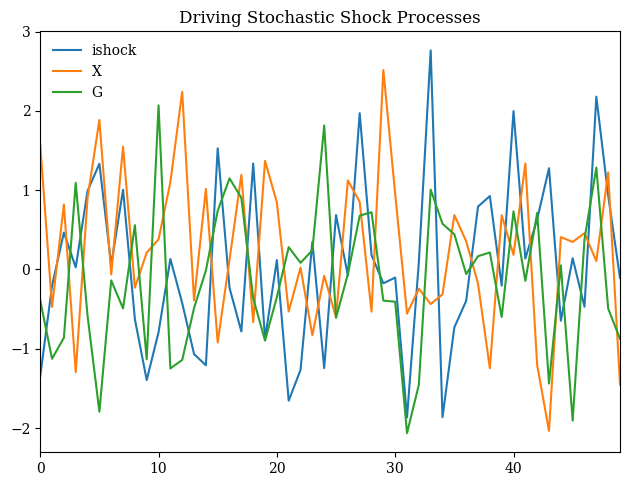

In [49]:
# Simulate one round of epsilons for the shocks (later we will repeat this step many times)

epsilons = {i: np.random.randn(T_sim + T - 1) for i in exogenous}
print(epsilons.keys(),'size of simul epsilon for MP shock', epsilons[exogenous[0]].shape)

for z in exogenous:
    plt.plot(epsilons[z][0:50], label = z)
plt.tight_layout()
plt.legend(framealpha=0)
plt.title('Driving Stochastic Shock Processes')
plt.show()

In [50]:
@njit(parallel=True)
def simul_shock(dX, epsilon):
    dX_flipped = dX[::-1].copy() # flip so we don't need to flip epsilon
    T = len(dX)
    T_simul = len(epsilon)
    Y = np.empty(T_simul - T + 1)
    # Numba paralell range
    for t in prange(T_simul - T + 1):
        
        Y[t] = np.vdot(dX_flipped, epsilon[t:t+T])

    return Y

def simulate(Gs, inputs, outputs, rhos, sigmas, T, T_simul):
    '''
    e.g.  data_simul = simulate(G, exogenous, outputs, rhos, sig, T, T_sim) 
    Simulate outputs for AR(1) inputs with processes given by (rho, sigma) vectors
    data_simul is a dict of simulated output paths given various shocks
    Gs      is the dict of G's (GE Jacobians)
    inputs  is the input list e.g. exogenous or shock_list = ['ishock','X','G']
    outputs is the output list  e.g. outputs    = ['pi','Y','i']
    rhos    is a dictionary with shocks persistence e.g. {'ishock': 0.9, 'X': 0.5}
    sigmas  is a dictionary with shocks standard deviations e.g. {'ishock': 1, 'X': 1}
    T       is the length of the impulse responses, the size of G
    T_simul is simulation length (length of simulated periods)
    '''
    epsilons = {i: np.random.randn(T_simul + T - 1) for i in inputs} # draw vectors of i.i.d. shocks N(0,1)
    simulations = {}
    
    for o in outputs:
        dXs = {i: sigmas[i]*(Gs[o][i] @ rhos[i] ** np.arange(T)) for i in inputs} 
        simulations[o] = sum(simul_shock(dXs[i], epsilons[i]) for i in inputs) # sum across all inputs
    
    return simulations

In [86]:
data_simul = simulate(G, exogenous, outputs, rhos, sig, T, T_sim)

# This returns a dictionary with keys of each variable simulated
data_simul.keys()

data_simul['i'].shape ## each contains a simulated time series

(156,)

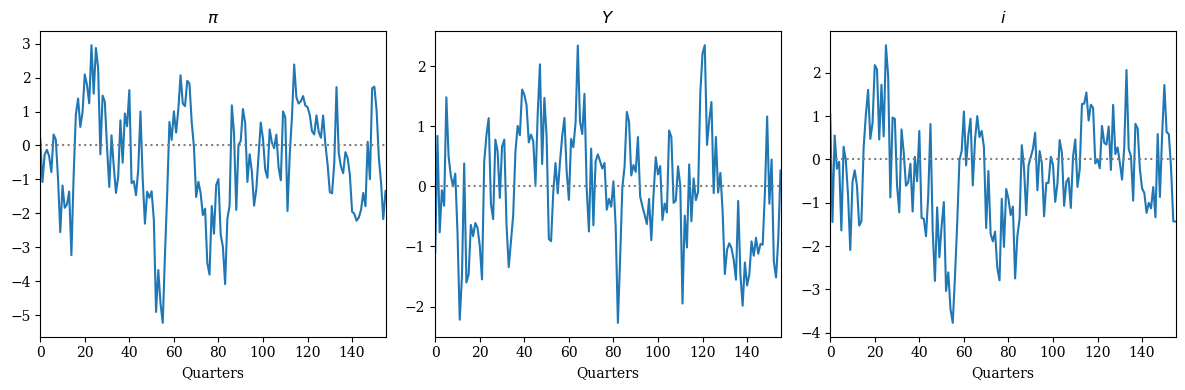

In [60]:

# plot
Tplot = 1001
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
plt.plot(data_simul['pi'][:Tplot])
plt.title(r'$\pi$')
plt.axhline(y=0, color='#808080', linestyle=':')
plt.xlabel('Quarters')
plt.subplot(1,3,2)
plt.plot(data_simul['Y'][:Tplot])
plt.title(r'$Y$')
plt.axhline(y=0, color='#808080', linestyle=':')
plt.xlabel('Quarters')
plt.subplot(1,3,3)
plt.plot(data_simul['i'][:Tplot])
plt.title(r'$i$')
plt.axhline(y=0, color='#808080', linestyle=':')
plt.xlabel('Quarters')
plt.tight_layout()
plt.show()

## Estimation on simulated data

Here we estimate the HA model on simulated data to make sure that our estimation procedure makes sense since we should recover from the estimation the parameters that we defined to simulate the model time series above.

Given the model jacobian and the data, evaluating the posterior is done in 4 steps.

In [65]:
print('We used the following parameters to simulate data_simul above on time series', data_simul.keys())
print('sigmas',sig,'rhos',rhos)

We used the following parameters to simulate data_simul above on time series dict_keys(['pi', 'Y', 'i'])
sigmas {'ishock': 1.0, 'X': 0.5, 'G': 0.2} rhos {'ishock': 0.7, 'X': 0.8, 'G': 0.7}


In [67]:
from sequence_jacobian import estimation as ssj_est

# Parameters of estimation
shock_series = [('ishock', 1), ('X', 1), ('G', 1)]
priors = [('Uniform',0,2),('Uniform',0,2),('Uniform',0,2),('Uniform',0,2),('Uniform',0,2),('Uniform',0,2)]
bounds = [(0.05,1.5),(0.01,0.99),(0.05,1.5),(0.01,0.99),(0.05,1.5),(0.01,0.99)]
x_guess = x0.copy()
x = x_guess

# Store data in an array
data = np.zeros((T_sim,3))
data[:,0] = data_simul['pi']
data[:,1] = data_simul['Y']
data[:,2] = data_simul['i']

In [75]:
x0
data.shape
len(shock_series)
for shock_name, order in shock_series:
    print(shock_name,order)

ishock 1
X 1
G 1


__Preliminary__: extract ARMA (Auto Regressive) coefficients of the *shock process* which follows $Z_t = \rho Z_{t-1} + \sigma\epsilon_t$. 

`get_shocks_arma(x, shock_series)` where `shock_series = [('ishock', 1), ('X', 1), ('G', 1)]` and `x = np.array([1,0.7, 0.5,0.8, 0.2,0.7])` are the parameter guesses defined above.

Note that we could have allowed for a more general process that doesn't just have a shock and the AR accumulation, but rather one in which shocks themselves enter as MA, if we had a process higher than an AR(1) 

In [70]:
def get_shocks_arma(x, shock_series):
    ix, ishock = 0, 0
    sigmas, arcoefs, macoefs = np.zeros((3,len(shock_series)))
    for shock_name, order in shock_series:
        sigmas[ishock] = x[ix]
        ix +=1
        if order >= 1:
            arcoefs[ishock] = x[ix]
            ix += 1
        if order >= 2:
            macoefs[ishock] = x[ix]
            ix += 1
        ishock += 1
    return sigmas, arcoefs, macoefs

In [81]:
# extract shock parameters from x; order: always sigma first, then AR coefs, then MA coefs
sigmas, arcoefs, macoefs = get_shocks_arma(x, shock_series)
print(x)
print('shock_series (name, order)',shock_series)
print('sigmas',sigmas)
print('arcoefs',arcoefs)
print('macoefs', macoefs)

[1.  0.7 0.5 0.8 0.2 0.7]
shock_series (name, order) [('ishock', 1), ('X', 1), ('G', 1)]
sigmas [1.  0.5 0.2]
arcoefs [0.7 0.8 0.7]
macoefs [0. 0. 0.]


In [92]:
# extra parameters
T_irf = T - 20
n_se,n_sh = len(outputs), len(shock_series)  # outputs   = ['pi','Y','i'] shock_list = ['ishock','X','G']
meas_error = np.zeros(n_se)                  # set measurement error to zero   
print(arcoefs.size, macoefs.size)

3 3


Note that `n_sh` is the number of shocks series, and `n_se` is the number of output series.

__Step 1__: compute the MA representation of G storing all the IRFs

Our goal is to run 

`As = step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh)`

This will be an array with dimension $T\times n_o\times n_z$ , where for each input shock and output series we store the IRF

$$ dX[o,i] = G[o][i] @ dZ[i]$$ 

Here we want to make sure that we are generating a shock path given the parameters specified, and checking that it doesn't explode (i.e. that it is stationary) or that we don't have $Z_T\rightarrow \infty$ as $T\rightarrow \infty$.

Note that to build an ARMA process

$$ x^z_t = AR_z^\text{term} + MA_t^\text{term}$$

where $ AR_t^\text{term} = \sum_l \rho_l x_{t-1-l}$

In [87]:
def step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh):
    ''' Compute the MA representation given G '''

    # Compute MA representation of outcomes in As
    As = np.empty((T_irf, n_se, n_sh)) # initialize
    
    # generate one for each of the n_sh shocks z
    for i_sh in range(n_sh):

        arma_shock = arma_irf(np.array([arcoefs[i_sh]]), np.array([macoefs[i_sh]]), T)

        if np.abs(arma_shock[-1]) > 1e20:
            raise Warning('ARMA shock misspecified, leading to explosive shock path!')

        # store for each (time) series of outcomes
        shockname = shock_series[i_sh][0] # Recall shock_series e.g. [('ishock', 1), ('X', 1), ('G', 1)]
        for i_se in range(n_se):
            As[:, i_se, i_sh] = (G[outputs[i_se]][shockname] @ arma_shock)[:T_irf] # dX[o,i] = G[o][i] @ dZ[i]

    return As

@njit
def arma_irf(ar_coeff, ma_coeff, T):  # NOTE: these need to be numpy.ndarrays
    """ Generates shock IRF for any ARMA process, of size T,1 """
    x = np.empty((T,))
    n_ar = ar_coeff.size
    n_ma = ma_coeff.size
    sign_ma = 1                             # in SW all MA coefficients are multiplied by -1
    for t in range(T):
        if t == 0:
            x[t] = 1  # start the sequence with a unit shock
        else:
            ar_sum = 0 # auto regressive component
            for i in range(min(n_ar, t)):
                ar_sum += ar_coeff[i] * x[t-1-i]
            ma_term = 0 # MA component
            if 0 < t <= n_ma:
                ma_term = ma_coeff[t-1]
            x[t] = ar_sum + ma_term * sign_ma
    return x

In [96]:
As = step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh)
# This has again shape T , n_o, n_z, storing an IRF for each output series and input shock
As.shape

(480, 3, 3)

__Step 2__: compute the covariance matrix of the model

Which represents the following object 

$$\operatorname{Cov}\left(d\tilde{\mathbf{X}}_{t},d\tilde{\mathbf{X}}_{t^{\prime}}\right)=\sum_{s=0}^{T-1-\left(t^{\prime}-t\right)}\left(d\mathbf{X}_{s}\right)\left(d\mathbf{X}_{s+t^{\prime}-t}\right)^{\prime}$$

or in particular, for any two series, and for any lag, it contains

$$ \operatorname{Cov}\left(Y_{t},X_{t+l}\right)={Cov}\left(Y_{t},X_{t+l}|\left\{ \sigma_{z}\right\} _{z}\right)=\mathbb{E}\left[Y_{t}X_{t+l}\right]=\sum_{z=1}^{2}\sum_{s=0}^{T-1}m_{s}^{x,z}\mathbb{E}\left[\epsilon^{z}\epsilon^{z\prime}\right]m_{s+l}^{y,z}=\sum_{z=1}^{2}\sigma_{z}^{2}\sum_{s=0}^{T-1}m_{s}^{x,z}m_{s+l}^{y,z}$$

Hence all we need to feed in are the $\sigma$s for each shock as well as the MA coefficients, which in our case, are simply the IRFs. 

This $\Sigma$ matrix will now be $T,n_o,n_o$ where now $T$ represents the lags, and computes that variance covariance among all $n_o$, integrating out all the shocks. 

In [99]:
Sigma = ssj_est.all_covariances(As, sigmas)
Sigma.shape

(480, 3, 3)

In [114]:
for i_o,o in enumerate(outputs):
    print(o,i_o)

pi 0
Y 1
i 2


standard deviations for each shock: diag at T = 0 [1.43720763 1.00051695 1.00692227]


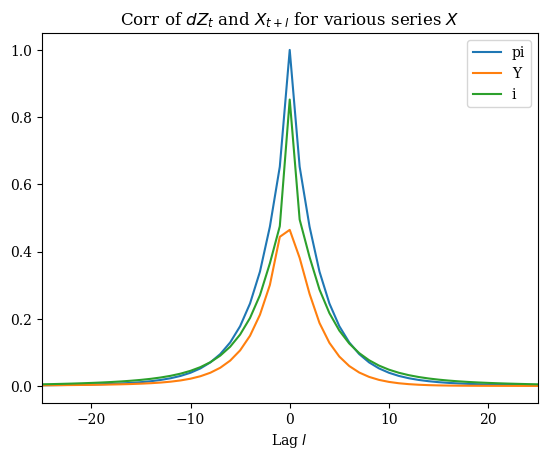

In [122]:
sd = np.sqrt(np.diag(Sigma[0, ...]))
print('standard deviations for each shock: diag at T = 0',sd)
correl = (Sigma/sd)/(sd[:, np.newaxis])

ls = np.arange(-25, 26)
corrs_l_positive = correl[:26, 0, :]
corrs_l_negative = correl[25:0:-1, :, 0]
corrs_combined = np.concatenate([corrs_l_negative, corrs_l_positive])

for i_o,o in enumerate(outputs):
    plt.plot(ls, corrs_combined[:, i_o], label= o)
plt.legend()
plt.title(r'Corr of $dZ_t$ and $X_{t+l}$ for various series $X$')
plt.xlabel(r'Lag $l$')
plt.show()

__Step 3__: compute log-likelihood for a single $\theta$

In [127]:
# Recall data is just the three series that we have faked to match the model's output
data.shape

(156, 3)

In [128]:
def step3_est(Sigma, y, sigma_o=None):
    # Sigma = V(θ), and y = data time series that we feed, with shape To,O (one col per outcome)
    To, O = y.shape
    loglik = (ssj_est.log_likelihood(y, Sigma, sigma_o) - (To * O * np.log(2 * np.pi))/2)
    return loglik

In [129]:
loglik = step3_est(Sigma, data, sigma_o=None)

In [130]:
loglik

-343.95517395035074

__Step 4__: adding the log-prior to the log-likelihood

In [132]:
def log_priors(x, priors_list):
    
    """This function computes a sum of log prior distributions that are stored in priors_list.
    Example: priors_list = {('Normal', 0, 1), ('Invgamma', 1, 2)}
    and x = np.array([1, 2])"""
    
    assert len(x) == len(priors_list)
    sum_log_priors = 0
    for n in range(len(x)):
        dist = priors_list[n][0]
        mu = priors_list[n][1]
        sig = priors_list[n][2]
        if dist == 'Normal':
            sum_log_priors += - 0.5 * ((x[n] - mu)/sig)**2
        elif dist == 'Uniform':
            lb = mu
            ub = sig
            sum_log_priors += - np.log(ub-lb)
        elif dist == 'Invgamma':
            s = mu
            v = sig
            sum_log_priors += (-v-1) * np.log(x[n]) - v*s**2/(2*x[n]**2)
        elif dist == 'Gamma':
            theta = sig**2 / mu
            k = mu / theta
            sum_log_priors += (k-1) * np.log(x[n]) - x[n]/theta
        elif dist == 'Beta':
            alpha = (mu*(1 - mu) - sig**2) / (sig**2 / mu)
            beta = alpha / mu - alpha
            sum_log_priors += (alpha-1) * np.log(x[n]) + (beta-1) * np.log(1-x[n])
        else:
            raise ValueError('Distribution provided is not implemented in log_priors!')

    if np.isinf(sum_log_priors) or np.isnan(sum_log_priors):
        print(x)
        raise ValueError('Need tighter bounds to prevent prior value = 0')
    return sum_log_priors

In [142]:
log_posterior = loglik + log_priors(x, priors)
print('log_posterior,loglik,log_priors',log_posterior,loglik,log_priors(x, priors))
print('x parameters guessed',x)
print('priors chosen for each parameter', priors )

log_posterior,loglik,log_priors -348.1140570337104 -343.95517395035074 -4.1588830833596715
x parameters guessed [1.  0.7 0.5 0.8 0.2 0.7]
priors chosen for each parameter [('Uniform', 0, 2), ('Uniform', 0, 2), ('Uniform', 0, 2), ('Uniform', 0, 2), ('Uniform', 0, 2), ('Uniform', 0, 2)]


Putting this all together, we'd like to get the posterior using

`log_posterior = loglik_f(x, data, outputs, shock_series, priors, T, G)` 

This function proceeds in four steps

0. Prelim: extract shock parameters from x param vector guess
    `sigmas, arcoefs, macoefs = get_shocks_arma(x,...)`

1. Step 1: compute the MA representation of G storing all the IRFs
    `As = step1_est(G, arcoefs, macoefs, ....)`

2. Step 2: compute the covariance matrix of the model 
    `Sigma = ssj_est.all_covariances(As, sigmas)`

3. Step 3: compute log-likelihood for a single $\theta$
    `loglik = step3_est(Sigma, data...)`

4. Step 4: compute the posterior by adding the log prior to the log likelihood
    `log_posterior = loglik + log_priors(x, priors_list)`

In [155]:
def loglik_f(x, data, outputs, shock_series, priors_list, T, G):
    '''
    Inputs:
    x     : params to evaluate, e.g. with rho and sigmas for 3 shocks [1. , 0.7, 0.5, 0.8, 0.2, 0.7] 
    data  : T,n_o matrix with empirical time series, e.g. with simulated or real π,Y,i, data is T,3
    outputs: list with keys for output time series names, e.g. ['pi', 'Y', 'i']
    shock_series: list with keys for shock series and order e.g. [('ishock', 1), ('X', 1), ('G', 1)]
    prior_list: priors corresponding to each of the params in x, e.g.  [('Uniform', 0, 2),...]
    Returns:
    log_posterior of the log-likeligood function at a candidate θ = x vector
    '''
    
    T_irf = T - 20 # burn
    
    n_se,n_sh = len(outputs), len(shock_series) # number of shocks and output time series
    
    meas_error = np.zeros(n_se)                  # set measurement error to zero (this is u)

    # Prelim: extract shock parameters from x; order: always sigma first, then AR coefs, then MA coefs
    sigmas, arcoefs, macoefs = get_shocks_arma(x, shock_series)

    # Step 1: compute the MA representation of G storing all the IRFs
    As = step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T_irf, n_se, n_sh)

    # Step 2: compute the covariance matrix of the model 
    Sigma = ssj_est.all_covariances(As, sigmas)

    # Step 3: compute normal log-likelihood for a single θ
    log_likelihood = step3_est(Sigma, data, sigma_o=meas_error)

    # Step 4: compute the posterior by adding the log prior to the log likelihood
    log_posterior = log_likelihood + log_priors(x, priors_list)
    
    return log_posterior

In [158]:
log_posterior = loglik_f(x, data, outputs, shock_series, priors, T, G)
log_posterior

-348.1140570337104

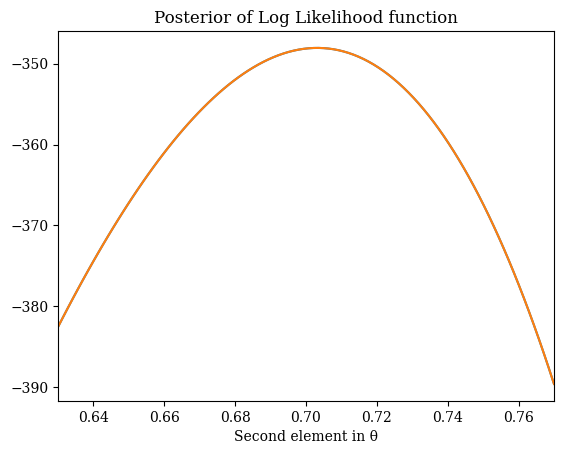

In [173]:

ll = np.linspace(x[1]*0.9,x[1]*1.1,100)
log_posteriors = np.empty(100)
xxx = x.copy()
for il,l in enumerate(ll): 
    xxx[1] = l
    log_posteriors[il] = loglik_f(xxx, data, outputs, shock_series, priors, T, G)
    
plt.plot(ll,log_posteriors)
plt.title('Posterior of Log Likelihood function')
plt.xlabel('Second element in θ')
plt.show()

## Estimation: Numerical Optimization of the Posterior of the Likelihood Function
Depending on which parameters we want to estimate, we might not have to recompute the model jacobian $G$ at every evaluation of the log-posterior:
- if we estimate parameters of the shock process alone we can keep $G$ fixed
- if we estimate parameters of blocks others than the household blocks (e.g. the degree of nominal rigidities shaping the slope of the NKPC), we need to recompute the model jacobian $G$ but we can re-use the same jacobian of the household block
- if we estimate parameters of the household block, we need to recompute the whole jacobian $G$ at every evaluation (this will be slow!)

The next function uses a numerical optimization routine to find the parameters that maximize the log-posterior. It also computes standard errors using the Hessian of the log-posterior function.

In [192]:
def estimate(outputs, data, x_guess, shock_series, priors_list, T, 
             G = None, params=None, jac_info=None, sd=True, data_demean_f=False, **kwargs):
    '''
    Example
    result, x_sd, nfev = estimate(outputs, data, 0.9*x_guess, shock_series, priors, T, G=G, bounds=bounds,sd=False)
    Defines objective(x), and mimimizes it via opt.minimize(objective, x_guess, **kwargs)
    params = bounds for params
    jac_info is a dictionary with all jacobian function as a dictionary jacobian.get_G(jac_info['block_list']...

    '''
    
    if G is None and jac_info is None:
        raise ValueError('Need at least G or jac_info and params as input!')
        
    # If we do not need to re-compute the model jacobian G for a x_guess (if we are only estimating shocks)
    if G is not None:
        def objective(x): 
            # we simply want to minimize the - likelihood's posterior
            return - loglik_f(x, data, outputs, shock_series, priors_list, T, G)
        
    # If we do...
    else:
        
        # Store model jacobian when necessary
        n_params = len(params)
        last_x_params = [np.zeros(n_params)] # initialize
        last_G = [{}] 
                
        def objective(x):

            # check whether we estimate the intercept of the data or whether it is de-meaned already
            if data_demean_f == False:
                data_adj = data.copy()
            else: 
                data_adj = data_demean_f(x,data)
                            
            # Update parameters 
            x_params = x[-n_params:] # will be used to update ss dictionary ss.update({param: x_params[j]...)
            
            # Check whether params have changed or not since last iteration
            
            if not np.allclose(x_params, last_x_params[0], rtol=1e-12, atol=1e-12):
            
                # write new parameters into ss dictionary and recompute jacobians
                ss = jac_info['ss'].copy()
                ss.update({param: x_params[j] for j, param in enumerate(params)})
                
                # Compute model jacobian G given new ss params
                # This one is easy, keep all block def the same, update ss params
                
                G = jacobian.get_G(jac_info['block_list'], 
                                   exogenous=jac_info['exogenous'], 
                                   unknowns =jac_info['unknowns'], 
                                   targets=jac_info['targets'], 
                                   T=jac_info['T'], 
                                   ss=ss, 
                                   outputs=outputs)

                # Store for later
                last_x_params[0] = x_params.copy()
                last_G[0] = G

            else: 

                # if they have not changed since last iteration, re-use the G from before
                G = last_G[0]

            # Compute log likelihood given the recomputed G and potentially adjusted data
            return - loglik_f(x, data_adj, outputs, shock_series, priors_list, T, G)
            
    # minimize objective
    
    result = opt.minimize(objective, x_guess, **kwargs)

    # Compute standard deviation numerically -- if required
    
    if sd:
        # get the info matrix (i.e. the hessian)
        H, nfev_total = hessian(objective, result.x, nfev=result.nfev, f_x0=result.fun)
        # invert the info matrix to get the variance covariance matrix
        Hinv = np.linalg.inv(H) 
        # square root of diagonal of VCE to get the SErrors 
        x_sd = np.sqrt(np.diagonal(Hinv))
    else:
        nfev_total = result.nfev
        x_sd = np.zeros_like(result.x)
        
    return result, x_sd, nfev_total

Remember from Econometrics 101 (e.g. http://www.sherrytowers.com/mle_introduction.pdf)

- The information matrix if the (negative) of the expected value of the Hessian (in our case we do not need the - because our objective is "minus" the likelihood).

$$[I(\theta)]=-E[H(\theta)]$$ 

- The Hessian is the matrix of second derivatives of the likelihood function (in our case, we will use `objective` which is - the likelihood)

$$ H(\theta)=\frac{\partial^{2} \ln \mathcal{L}(\theta)}{\partial \theta \partial \theta^{\prime}}$$ 

- The variance covariance matrix of MLE is simply the inverse of the information matrix 

$$ \begin{aligned}
\operatorname{var}(\theta) &=[I(\theta)]^{-1} \\
&=(-E[H(\theta)])^{-1} \\
&=\left(-E\left[\frac{\partial^{2} \ln \mathcal{L}(\theta)}{\partial \theta \partial \theta^{\prime}}\right]\right)^{-1}
\end{aligned}$$ 

- The MLE equivalent of White's Robust standard errors is 

$$ \operatorname{var}(\hat{\theta})=I^{-1} \frac{\partial \mathcal{L}}{\partial \theta} \frac{\partial \mathcal{L}^{\prime}}{\partial \theta} I^{-1}$$ 

- To get the standard errors of parameters, all we have to do is take the square root of the diagonal of $\operatorname{var}(\theta) $

Let's use it and compare our estimates with the true parameters.

In [199]:
t = time.time()
result, x_sd, nfev = estimate(outputs, data, 0.9*x_guess, shock_series, priors, T, G=G, bounds=bounds,sd=False)

x = result.x
print(f'Time for estimation {round(time.time() - t)}s')    
print('Optimization converged?', (result.success))
print('Maximum distance between estimates and true parameters = % .3f' %(np.max(x-x0)))

result

Time for estimation 2s
Optimization converged? True
Maximum distance between estimates and true parameters =  0.043


      fun: 344.75208490396784
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 4.66116032e-04, -2.21689332e-04,  1.98951965e-04,  3.12638802e-04,
        1.08002496e-04,  2.84217093e-05])
  message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 175
      nit: 19
     njev: 25
   status: 0
  success: True
        x: array([0.98427418, 0.70607045, 0.54264801, 0.78649898, 0.18181702,
       0.59564653])

In [207]:
print('estimates',x)
print('guess',0.9*x_guess)
print('truth',x_guess)


estimates [0.98427418 0.70607045 0.54264801 0.78649898 0.18181702 0.59564653]
guess [0.9  0.63 0.45 0.72 0.18 0.63]
truth [1.  0.7 0.5 0.8 0.2 0.7]


The optimization has converged. A good sanity check is that the (objective function's) jacobian is small along all dimensions; if not, that suggests that our bound was too restrictive. 

Our parameter estimates are close to the truth but not exactly equal.

Recall all this was based on a single draw for the aggregate time series produced from a single run of 

`data_simul = simulate(G, exogenous, outputs, rhos, sig, T, T_sim)`

which contained

`epsilons = {i: np.random.randn(T_sim + T - 1) for i in exogenous}` 

Imagine that we got a particularly weird series if we only used a single simulation, then some of the difference might be due to noise (simulation error). To deal with this, let's estimate the model several times using *different* simulations and see what the posterior distribution looks like. Let's simulate $40$ samples of 156 periods, which amounts to 39 years if we have quarterly data. This is the size of our sample from 1966Q1 to 2004Q4 and compute `x_simul` of $[n_\text{param} , N_\text{simulations}]$, that is the parameters estimated in each of our 40 simulated samples. 

Number of simulations: 40
Iteration: 0
Iteration: 8
Iteration: 16
Iteration: 24
Iteration: 32
Time for reestimation 27s


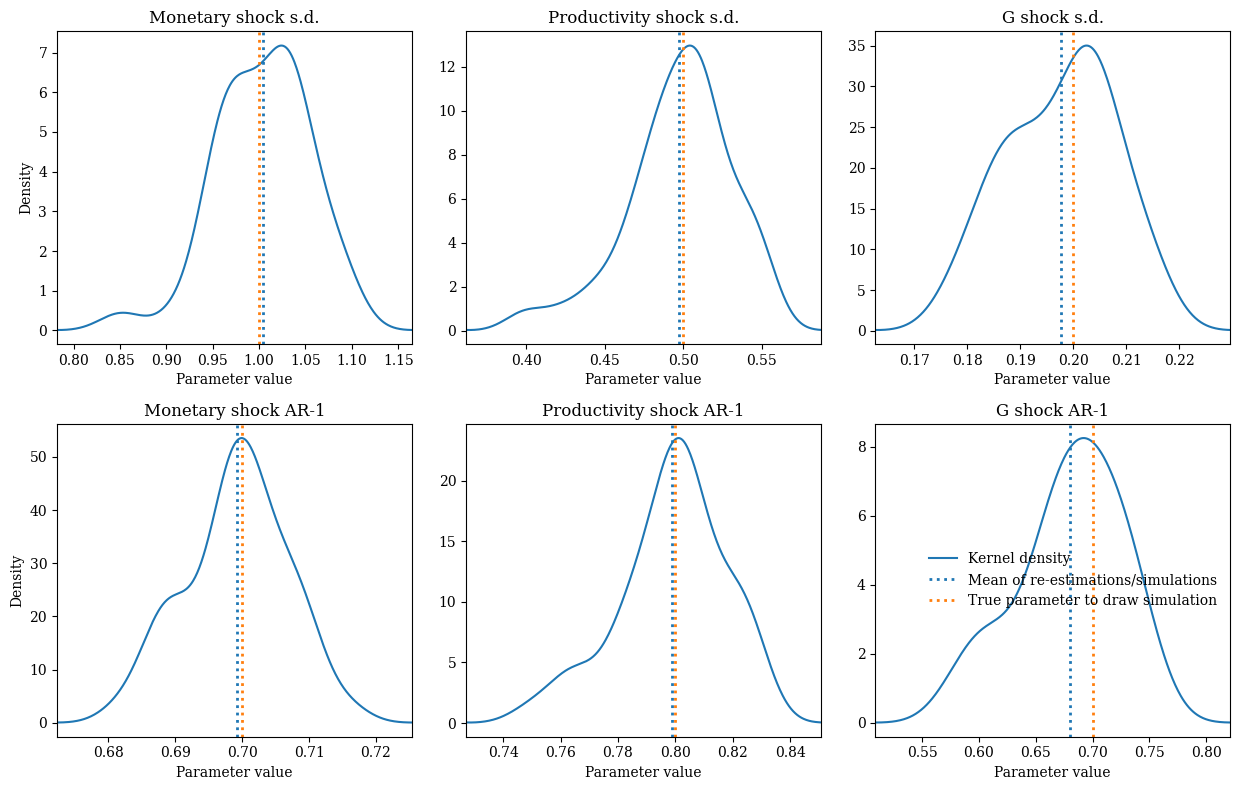

In [215]:
# Parameters
T_sim = 156  # has to be less than T 

N_simul = 40
print(f'Number of simulations: {N_simul}')

# Estimate parameters on simulated data
success_simul = np.zeros(N_simul)
x_simul = np.zeros((len(x_guess),N_simul)) # store [n param , N simulations]

t = time.time()
for i in range(N_simul):
    
    if i%max(np.trunc(N_simul/5),1) == 0: print(f'Iteration: {i}')
    
    # Get simulated data
    data_simul = simulate(G, exogenous, outputs, rhos, sig, T, T_sim)
    
    data = np.zeros((T_sim,3))
    data[:,0] = data_simul['pi']
    data[:,1] = data_simul['Y']
    data[:,2] = data_simul['i']
    
    # Use data in each simulation to estimate parameters
    result, _, _ = estimate(outputs, data, 0.9*x_guess, shock_series, priors, T, G=G, bounds=bounds,sd=False)
    
    success_simul[i] = result.success # check whether it converged
    x_simul[:,i] = result.x           # stored estimates

elapsed = time.time() - t
print(f'Time for reestimation {round(elapsed)}s')    

# Compute kernel density (like the non-parametric kdensity in Stata) of x_simul over the N_simul simulations

kde = sm.nonparametric.KDEUnivariate(x_simul[0])
kde.fit()

kernel_support = np.zeros((x_simul[:,0].shape[0],kde.support.shape[0]))
kernel_density = np.zeros((x_simul[:,0].shape[0],kde.support.shape[0]))

for i in range(x_simul[:,0].shape[0]):
    kde = sm.nonparametric.KDEUnivariate(x_simul[i]) # for each parameter, generate a kdensity
    kde.fit()
    kernel_support[i] = kde.support # x-axis for param i (value)
    kernel_density[i] = kde.density # y-axis for param i (density)
    
# plot
plt_title = ['Monetary shock s.d.', 'Monetary shock AR-1', 'Productivity shock s.d.', 'Productivity shock AR-1', 'G shock s.d.', 'G shock AR-1']
idx = [0,2,4,1,3,5]             # change the order in which they are display
plt.figure(figsize=(12.5, 8))

# for each parameter
for i in range(x_simul[:,0].shape[0]):
    plt.subplot(2,3,i+1)
    plt.plot(kernel_support[idx[i]],kernel_density[idx[i]],label='Kernel density')
    plt.axvline(np.mean(x_simul[idx[i]]), linewidth = 2, color = 'tab:blue', linestyle = ':',label='Mean of re-estimations/simulations')
    plt.axvline(x0[idx[i]], linewidth = 2, color = 'tab:orange', linestyle = ':',label='True parameter to draw simulation')
    plt.title(plt_title[idx[i]])
    plt.xlabel(r'Parameter value')
    if (i == 0) | (i == 3): plt.ylabel(r'Density')
plt.legend(framealpha=0)
plt.tight_layout()
plt.show()

Not bad at all! At least we know that our estimation routine works

## Estimation on actual data

This is for you to do; follow these steps

__Import series from FRED__

__Clean and detrend series__

__Estimate shocks only__

We first estimate shocks parameters only of the RA and HA models (i.e. without needing to recompute $G$ jacobians.

__Estimate shocks and parameters__

Now it becomes a bit more tricky because we have to recompute the model jacobian for each evaluation of the posterior likelihood. A naive approach would be to recompute the jacobian of the entire model every time. A faster approach is to re-use the jacobians of blocks in which parameters are not estimates. In the HA model, this makes a big difference!


## Post-estimation results

This is for you to do; follow these steps (I'm leaving you some code to help you get through this part)

We will compute a forecast error decomposition and a historical decomposition using the HA model in which we estimated both shocks are parameters. 

__Forecast error variance decomposition__

- This is simply a fancy way of saying that we want to compare the effect of a partial derivative relative to a total derivative in an outcome when we change either just one input or all inputs.

- We can write $y$ as an $MA(\infty)$ representation which sums over lags across all periods, and also via the matrix-vector multiplication inside the sum, across the different shocks

$$ {y_{t}=\Psi_{0}+\Psi_{1}s_{t}=\Psi_{0}+\Psi_{1}\sum_{s=0}^{\infty}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}\epsilon_{t-s}} \implies dy_{t}=\Psi_{1}\sum_{s=0}^{\infty}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}\epsilon_{t-s}$$

- Recall our IRF to shock $j$  is what we could get from the Jacobian was

$$m_{ij}^h={\operatorname{IRF}(j,h)\equiv\mathbb{E}\left[y_{i,t+h}\mid s_{t-1},\epsilon_{j,t}=1\right]-\mathbb{E}\left[y_{i,t+h}\mid s_{t-1}\right]}=[\Psi_{1}\left(\Phi_{1}\right)^{h}\Phi_{\epsilon}e_{j}]_i \iff dy_{i,j} = G_{i,j} dZ_{j} $$

- SSJ gives us that shocked variables $\left\{ dZ_{t}\right\}$  are $MA(\infty)$ in iid structural innovation vectors $\epsilon_{t}$. Given certainty equivalence, so is also any endogenous $\left\{ dX_{t}\right\}$  where $M^{Z}(\theta)$ and $M^{X}(\theta)$ are simply the Jacobians, and related to each other via the implicit function theorem giving us the GE matrix G mapping shock Z to outcome X. 

$$dZ_{t}=\sum_{s=0}^{\infty}M_{s}^{Z}(\theta)\epsilon_{t-s},\quad dX_{t}=\sum_{s=0}^{\infty}M_{s}^{X}(\theta)\epsilon_{t-s},\quad\mathbf{G}=-\mathbf{H}_{X}^{-1}\mathbf{H}_{Z},\quad M^{X}(\theta)=G^{X,Z}(\theta)M^{Z}(\theta)$$

- Recall  we extracted all these IRF coefficients  of the MA representation and stacked into a big matrix $A_s$. $As[6, 3, 5]$ gives the impact of shock 5, 6 periods ago, on observable 3 today

`As[:, i_se, i_sh] = (G[outputs[i_se]][shockname] @ arma_shock)[:T_irf] # dX[o,i] = G[o][i] @ dZ[i]`

- I suspect this means that we can simply write the total derivative (with all shocks changing) as well as the "partial" derivative (with only one shock changing)

$$ dy^{o} = \sum_s \sum_z A_s[o,z] ,\quad dy^{o,z} = \sum_h  A_s[o,z] $$

- What drives, “on average”, movements in $y$ at different horizons? (e.g. what drives output at business cycle frequencies?). This is already our $MA(h-1)$ representation of the shock (because of perfect foresight)! with the coefficients corresponding to the IRFs $dy_{i,j} = G_{i,j} dZ_{j}$

$$\tilde{e}_{t\mid t-h}=y_{t}-\mathbb{E}_{t-h}\left[y_{t}\right]=\Psi_{1}\sum_{s=0}^{h-1}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}\epsilon_{t-s} \implies A_s = \Psi_{1}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}$$

- Recall also that given $d\mathbf{X}^{o,z}=\mathbf{G}^{o,z}d\mathbf{Z}^{z}$ we had that the covariance matrix  was simply a way to calculate the relationship (at different lags) between any two outcomes in $y$. We wrote $$\operatorname{Cov}\left(d\tilde{\mathbf{X}}_{t},d\tilde{\mathbf{X}}_{t^{\prime}}\right)=\sum_{s=0}^{T-1-\left(t^{\prime}-t\right)}\left(d\mathbf{X}_{s}\right)\left(d\mathbf{X}_{s+t^{\prime}-t}\right)^{\prime},\iff \operatorname{Cov}\left(dX_{t},dY_{t^{\prime}}\right)=\sum_{s=0}^{\infty}M_{s}^{X}(\theta)\cdot M_{s+t^{\prime}-t}^{Y}(\theta)$$

- More explicitly in terms of parameters of the shocks and our IRFs

$$ \operatorname{Cov}\left(Y_{t},X_{t+l}\right)={Cov}\left(Y_{t},X_{t+l}|\left\{ \sigma_{z}\right\} _{z}\right)=\mathbb{E}\left[Y_{t}X_{t+l}\right]=\sum_{z=1}^{3}\sum_{s=0}^{T-1}m_{s}^{x,z}\mathbb{E}\left[\epsilon^{z}\epsilon^{z\prime}\right]m_{s+l}^{y,z}=\sum_{z=1}^{3}\sum_{s=0}^{T-1}\sigma_{z}^{2}m_{s}^{x,z}m_{s+l}^{y,z}$$ 

- Similarly (but more simply), the forecast error variance decomposition is the share of the total variance of observable i contributed by shock j. Hence, we do not care anymore about the relation between any two outcomes $i,i'$ at different $t$ horizons but in an IRF sense (not in a "lag" news shock sense), all we care about are the *diagonal* elements!

$$FEVD{(i,j,h)=\frac{V_{i}|\text{j shock}}{V_{ii}|\text{ all shocks}}=\frac{\left[\Psi_{1}\sum_{s=0}^{h-1}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}e_{j}e_{j}^{\prime}\Phi_{\epsilon}^{\prime}\left(\Phi_{1}^{\prime}\right)^{s}\Psi_{1}^{\prime}\right]_{ii}}{\left[\Psi_{1}\sum_{s=0}^{h-1}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}\Phi_{\epsilon}^{\prime}\left(\Phi_{1}^{\prime}\right)^{s}\Psi_{1}^{\prime}\right]_{ii}}}$$

- We can do this at different horizons (e.g. one period ahead, deeper into the recession, in recovery) for different aggregates (output, labor demand, investment). This is the classical exercise of Smets and Wouters. 

- SSJ gives us FEVD at any horizon h directly from the Jacobians + MA representation 

$$ V(Y^y_{t}) = \operatorname{Cov}\left(Y^y_{t},Y^y_{t}\right)=\sum_{z=1}^{3}\sum_{s=0}^{T-1}(\sigma_{z} m_{s}^{y,z})^2,\quad m_{s}^{y,z} = A_s[y,z] $$ 

- Thus, for a single shock, we have that the absolute contribution of shock $z$ to the variance (the diagonal of the VE) of $y$ is

$$ V(Y^{y,z}_{t}) = \operatorname{Cov}\left(Y^{y,z}_{t},Y^{y,z}_{t}\right)=\sum_{s=0}^{T-1}(\sigma_{z} m_{s}^{y,z})^2,\quad m_{s}^{y,z} = A_s[y,z] $$

- Hence, all we have to do is compute the share of the total variance of $y$ at different horizons (not it's covariance with any other aggregate!) that can be explained with a single $z$ alone (like comparing a partial v.s. a total derivative).

$$ FEVD(y,z,h) = \frac{\sum_{s=0}^{T-1}(\sigma_{z} A_s[y,z])^2 }{\sum_{z=1}^{3}\sum_{s=0}^{T-1}(\sigma_{z} A_{s}[y,z])^2} $$

We implement this expression below, and plot it for different horizons and for different shocks

In [222]:
x_fevd = x.copy()

# extract shock MA parameters from x and the GE Jacobians (repeat prelim + step 1)
sigmas, arcoefs, macoefs = get_shocks_arma(x_fevd, shock_series)
As = step1_est(G, arcoefs, macoefs, shock_series, outputs, T, T - 20, len(outputs), len(shock_series))

# Compute forecast error (recall As[T,outputs,shocks])
# i.e. compute forecast error variance contributions for every shock and every series over time
FEV     = np.cumsum((As * sigmas) ** 2, axis=0)    # numerator: sum over time for a given shock
FEV_sum = np.sum(FEV, axis=2)                      # demoninator: sum over time AND shocks

FEV_sum[FEV_sum == 0] = np.inf

FEV_invsum_by_t_series_ra = 1 / FEV_sum         # normalize by the sum
FEV_norm = FEV_invsum_by_t_series_ra[..., np.newaxis] * FEV # numerator / denominator (repmat on shock dimension)


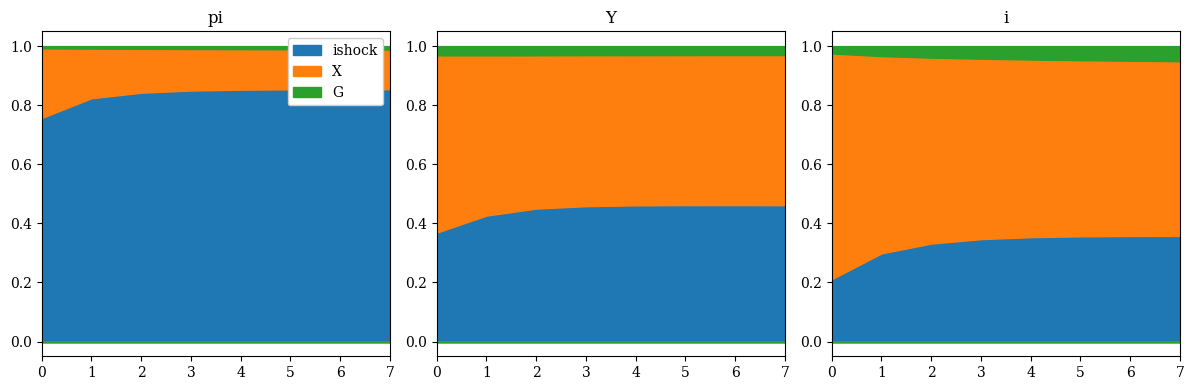

In [232]:
# plot Ds = FEV_norm[:horizon, ...] for each output and each shock

horizon = 8 # you probably want to do more
xaxis   = np.arange(horizon) # plot over horizon

Ds     = FEV_norm[:horizon, ...] # plot the FEV norm share upto a horizon (for each o,z)

Tshow, len_se, len_sh = Ds.shape
colors = {'ishock': 'C0','X': 'C1','G': 'C2'}
plt.figure(figsize=(12, 4))

# for each output
for i,s in enumerate(outputs):

    plt.subplot(1,3,1+i)
    series_fig = s
    i_se = outputs.index(series_fig)
    
    y_offset_pos = np.zeros_like(Ds[:,i_se,0])  # positive offset, collecting positive terms
    y_offset_neg = np.zeros_like(Ds[:, i_se, 0])  # negative offset, collecting negative terms

    # for each shock
    for i_sh in range(len_sh):

        sh = shock_series[i_sh][0]
        
        Ds_here = Ds[:,i_se,i_sh] # plot FEV norm share for each o,z
        
        # make sure it looks pretty
        
        y_offset = (Ds_here > 0) * y_offset_pos + (Ds_here < 0) * y_offset_neg
        y_offset_pos_ = y_offset_pos + np.maximum(Ds_here,0)
        y_offset_neg_ = y_offset_neg - np.maximum(-Ds_here,0)
        
        plt.fill_between(xaxis, y_offset_pos, y_offset_pos_, color=colors[sh], label=sh)
        plt.fill_between(xaxis, y_offset_neg, y_offset_neg_, color=colors[sh])
        y_offset_pos = y_offset_pos_
        y_offset_neg = y_offset_neg_

    if i == 0: plt.legend(framealpha=1)
    plt.title(series_fig);
    
plt.tight_layout()
plt.show()

It does not look that pretty, but notice that we have not introduced any more ingredients than the simple sticky-wage setup, and we have used *random* time series data to estimate the model's parameters. If we had used data that had more realistic covariances between variables (realistic pro-cyclicality of things). It is kind of interesting that with random data, TFP seems the dominant force... 

Obviously in the data, variables are going to move slower than in our random simulation, hence you might get more persistence and need to increase the horizon of the plots.

__Historical shock decomposition__

- we’d like to back out which shocks were likely driving historical data on $y_{t}$
- back out the most likely shock path $\epsilon_{0},\epsilon_{1},...$ that minimizes the distance 

$$ {\min_{\left\{ \epsilon_{t}\right\} }\sum_{s=0}^{T}\left\Vert y_{s}^{data}-\tilde{e}_{s\mid0}\left(\left\{ \epsilon_{t}\right\} \right)\right\Vert ^{2}}$$ 

- Where $\tilde{e}_{t\mid t-h}=y_{t}-\mathbb{E}_{t-h}\left[y_{t}\right]=\Psi_{1}\sum_{s=0}^{h-1}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon}\epsilon_{t-s} \implies A_s = \Psi_{1}\left(\Phi_{1}\right)^{s}\Phi_{\epsilon} \implies \tilde{e}_{t\mid t-h}=\sum_{s=0}^{h-1}A_s\epsilon_{t-s}$

- Note it's like trying to predict $\epsilon_t$ such that, given our $A_s$ for the model, we can fit the time series data best, so we are regressing essentially $y$ on the $A_s$ i.e. find regression coefficients $\epsilon_t$ such that 

$$  y_{t}^{data} = \sum_z \hat{y}^{o,z} = \sum_z \sum_{s=0}^{h-1}A^{o,z}_s\widehat{\epsilon}^z_{t-s} = \sum_{s=0}^{h-1}A_s\widehat{\epsilon}_{t-s}$$ 

- This delivers a $T\times n_z$ vector with a time series for each shock. And then we ask how much of each estimated shock is contributing to the total time series $\hat{y}^{o,z} = \sum_{s=0}^{h-1}A^{o,z}_s\widehat{\epsilon}^z_{t-s}$  v.s. overall $y^o$ for each output and shock. That is simply how much of the overall series is explained by each of the "fitted values" of $y$

- We are going to be doing a simple OLS regression where we are trying to back out a path of $\epsilon_t$ that, given the model's IRFs $G$ would deliver the path of aggregates
- Feeding in one shock at a time, can then construct a historical decomposition of the time series into shocks that explain it
- You can answer now "What share of shocks in the 1980s, 1990s, etc. were driven by technology v.s. demand v.s. investment shocks?"
- i.e. maybe TFP shocks have a harder time explaining aggregate dynamics around a time when certain two aggregates comove relative to another shock that nails it


In [233]:
def back_out_shocks(As, y, sigma_e=None, sigma_o=None, preperiods=0):
    """back_out_shocks : Calculates most likely shock paths of shocks if As is true set of IRFs

    Parameters
    ----------
    As : array (Tm*O*E) giving the O*E matrix mapping shocks to observables at each of Tm lags in the MA(infty),
            e.g. As[6, 3, 5] gives the impact of shock 5, 6 periods ago, on observable 3 today
    y : array (To*O) giving the data (already assumed to be demeaned, though no correction is made for this in the log-likelihood)
            each of the To rows t is the vector of observables at date t (earliest should be listed first)
    sigma_e : [optional] array (E) giving sd of each shock e, assumed to be 1 if not provided
    sigma_o : [optional] array (O) giving sd of iid measurement error for each observable o, assumed to be 0 if not provided
    preperiods : [optional] integer number of pre-periods during which we allow for shocks too. This is suggested to be at
            least 1 in models where some variables (e.g. investment) only respond with a 1 period lag.
            (Otherwise there can be invertibility issues)

    Returns
    ----------
    eps_hat : array (To*E) giving most likely path of all shocks
    Ds : array (To*O*E) giving the level of each observed data series that is accounted for by each shock
    """

    # Step 1: Rescale As and y
    
    To, Oy = y.shape
    Tm, O, E = As.shape
    assert Oy == O
    To_with_pre = To + preperiods

    A_full = construct_stacked_A(As, To=To_with_pre, To_out=To, sigma_e=sigma_e, sigma_o=sigma_o)
    if sigma_o is not None:
        y = y / sigma_o # re-scale by standard deviation to correct for measurement error
    y = y.reshape(To*O)

    # Step 2: Solve OLS to back out shocks
    # linalg.lstsq(x, y) computes x that solves x @ b = y, or the 2-norm || y - x b ||
    # essentially we are regressing y (outcomes) on As (A full matrix with IRF) to back out shocks from MA rep
    
    eps_hat = np.linalg.lstsq(A_full, y, rcond=None)[0]  # this is To*E x 1 dimensional array
    eps_hat = eps_hat.reshape((To_with_pre, E)) # want to get To x E vector with implied shocks

    # Step 3: Decompose data: how much is A[o,z] epsilon_z contributing to y_o time series? Fitted values!
    for e in range(E):
        A_full = A_full.reshape((To,O,To_with_pre,E))
        Ds = np.sum(A_full * eps_hat,axis=2)

    # Cut away pre periods from eps_hat
    eps_hat = eps_hat[preperiods:, :]

    return eps_hat, Ds

def construct_stacked_A(As, To, To_out=None, sigma_e=None, sigma_o=None, reshape=True, long=False):
    ''' We want As stacked into shape (To_out * O, To * E) for matrix multiplication'''
    Tm, O, E = As.shape

    # how long should the IRFs be that we stack in A_full?
    if To_out is None:
        To_out = To
    if long:
        To_out = To + Tm  # store even the last shock's IRF in full!

    # allocate memory for A_full
    A_full = np.zeros((To_out, O, To, E))

    for o in range(O):
        for itshock in range(To):
            # if To > To_out, allow the first To - To_out shocks to happen before the To_out time periods
            if To <= To_out:
                iA_full = itshock
                iAs = 0

                shock_length = min(Tm, To_out - iA_full)
            else:
                # this would be the correct start time of the shock
                iA_full = itshock - (To - To_out)

                # since it can be negative, only start IRFs at later date
                iAs = - min(iA_full, 0)

                # correct iA_full by that date
                iA_full += - min(iA_full, 0)

                shock_length = min(Tm, To_out - iA_full)

            for e in range(E):
                A_full[iA_full:iA_full + shock_length, o, itshock, e] = As[iAs:iAs + shock_length, o, e]
                if sigma_e is not None:
                    A_full[iA_full:iA_full + shock_length, o, itshock, e] *= sigma_e[e]
                if sigma_o is not None:
                    A_full[iA_full:iA_full + shock_length, o, itshock, e] /= sigma_o[o]
    if reshape:
        A_full = A_full.reshape((To_out * O, To * E))
    return A_full

In [ ]:
# Compute shock decomposition (you need to apply this to your historical data)

eps_hat_est, Ds = back_out_shocks(As, data, sigma_e=sigmas, sigma_o=None, preperiods=1)  # allow for 1 pre-period with inv 1 period in advance

xaxis = df.index[0].year + 0.25*np.arange(4*(df.index[-1].year-df.index[0].year+1)) # x-axis are time series y

# plot
Tshow, len_se, len_sh = Ds.shape
colors = {'ishock': 'C0','X': 'C1','G': 'C2'}
plt.figure(figsize=(12, 4))

# for each output
for i,s in enumerate(outputs):

    plt.subplot(1,3,1+i)
    series_fig = s
    i_se = outputs.index(series_fig)
    y_offset_pos = np.zeros_like(Ds[:,i_se,0])  # positive offset, collecting positive terms
    y_offset_neg = np.zeros_like(Ds[:, i_se, 0])  # negative offset, collecting negative terms

    # loop over shocks
    for i_sh in range(len_sh):

        sh = shock_series[i_sh][0]
        
        Ds_here = Ds[:,i_se,i_sh] # for each shock plot over time its contribution to it's outcome time series
        
        y_offset = (Ds_here > 0) * y_offset_pos + (Ds_here < 0) * y_offset_neg
        y_offset_pos_ = y_offset_pos + np.maximum(Ds_here,0)
        y_offset_neg_ = y_offset_neg - np.maximum(-Ds_here,0)
        plt.fill_between(xaxis, y_offset_pos, y_offset_pos_, color=colors[sh], label=sh)
        plt.fill_between(xaxis, y_offset_neg, y_offset_neg_, color=colors[sh])
        y_offset_pos = y_offset_pos_
        y_offset_neg = y_offset_neg_

    plt.plot(xaxis,data[:,i_se],color='black')
    if i == 0: plt.legend(framealpha=1)
    plt.title(series_fig);
    
plt.tight_layout();

(Some notes from Ludwig)

Things to be careful about in the estimation:
- watch out for bounds: for some parameter value we might not be able to compute the variance-covariance matrix. If you get an error try tighter bounds. 
- For estimations make sure $T>Tsimul$

Next things to add:
- Metropolis Hastings
- Standard errors?